<a href="https://www.kaggle.com/code/mohammednafayali/supply-chain-analytics-lightgbm-xgboost-ridge?scriptVersionId=351090828" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/datascikhan/e-commerce-delivery-and-shipping-data-2026/E-commerce_Delivery_Shipping_Data_2026.csv


### 1. Data Loading & Initial Inspection

* **What was done:**
  Loaded the raw CSV file into a pandas DataFrame named `df` and displayed the first 5 rows to visually inspect the data structure.
* **Why specific functions were used:**
  * `pd.read_csv()`: Converts tabular data from a CSV file into an in-memory DataFrame structure for data manipulation.
  * `df.head()`: Provides a quick sanity check of column headers, row formatting, and sample values without rendering the full dataset.

---

### 2. Dropping Primary Keys & Dataset Diagnostics

* **What was done:**
  Removed high-cardinality identifier columns (`order_id` and `customer_id`) and printed summary technical information about the dataset.
* **Why specific functions were used:**
  * `df.drop(columns=[...], axis=True)`: Unique ID strings carry zero generalizable predictive signal. Keeping them can lead to unnecessary memory overhead or potential model overfitting on primary key patterns.
  * `df.info()`: Diagnoses column data types (`float64`, `int64`, `object`), total row count ($50,000$), missing values (e.g., identifying that `return_reason` has missing entries), and memory usage.

In [2]:
df=pd.read_csv("/kaggle/input/datasets/datascikhan/e-commerce-delivery-and-shipping-data-2026/E-commerce_Delivery_Shipping_Data_2026.csv")
df.head()

,order_id,order_date,customer_id,customer_segment,customer_city,customer_country,warehouse_id,warehouse_city,product_category,product_weight_kg,...,package_size,payment_method,order_priority,weather_condition,customer_rating,return_requested,return_reason,delivery_attempts,warehouse_processing_hours,tracking_status
0,ORD-000001,2026-11-15,CUS-002353,Small Business,Tokyo,Japan,WH-004,Toronto,Home & Kitchen,8.23,...,Large,Digital Wallet,Normal,Snow,3,Yes,Late Delivery,2,25.1,Delivered
1,ORD-000002,2026-04-08,CUS-003258,Consumer,Vancouver,Canada,WH-007,Paris,Beauty,0.10,...,Small,Debit Card,Normal,Cloudy,5,No,NaN,1,25.9,Delivered
2,ORD-000003,2026-01-05,CUS-001221,Consumer,Houston,United States,WH-005,London,Home & Kitchen,5.51,...,Large,Debit Card,Low,Snow,4,Yes,Product Defect,1,31.5,Delivered
3,ORD-000004,2026-05-29,CUS-001717,Small Business,Delhi,India,WH-002,Los Angeles,Grocery,3.75,...,Large,Debit Card,Normal,Snow,3,No,NaN,1,12.6,In Transit
4,ORD-000005,2026-02-22,CUS-000716,Small Business,Nagoya,Japan,WH-006,Berlin,Beauty,0.10,...,Small,Credit Card,Normal,Storm,2,No,NaN,1,24.9,Delivered


In [3]:
df=df.drop(columns=["order_id","customer_id"],axis=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   order_date                  50000 non-null  object 
 1   customer_segment            50000 non-null  object 
 2   customer_city               50000 non-null  object 
 3   customer_country            50000 non-null  object 
 4   warehouse_id                50000 non-null  object 
 5   warehouse_city              50000 non-null  object 
 6   product_category            50000 non-null  object 
 7   product_weight_kg           50000 non-null  float64
 8   order_value_usd             50000 non-null  float64
 9   shipping_method             50000 non-null  object 
 10  carrier                     50000 non-null  object 
 11  distance_km                 50000 non-null  float64
 12  promised_delivery_days      50000 non-null  int64  
 13  actual_delivery_days        500

### 1. Library Imports

* **What was done:**
  Imported `matplotlib.pyplot` and `seaborn`, which are the standard Python data visualization libraries.
* **Why specific functions were used:**
  * `import matplotlib.pyplot as plt`: Provides underlying plotting engine functions (figure sizing, titles, axis rotation, display).
  * `import seaborn as sns`: Built on top of Matplotlib to create clean, statistical graphics with minimal code and custom color palettes.

---

### 2. Country-Wise Order Volume & Shipping Method Analysis (Count Plot)

* **What was done:**
  Created a grouped bar chart plotting order counts across customer countries, broken down (hue) by shipping method, using a custom color palette and angled x-axis labels.
* **Why specific functions were used:**
  * `plt.figure(figsize=(18, 8))`: Expands canvas width to ensure category names along the horizontal axis do not overlap or crowd.
  * `sns.set_palette('plasma')`: Applies a high-contrast sequential color scheme to distinguish shipping method categories clearly.
  * `sns.countplot(x=df['customer_country'], hue=df['shipping_method'])`: Automatically aggregates frequency counts for categorical combinations without requiring manual `groupby()` operations.
  * `plt.xticks(rotation=45)`: Tilts country names by 45 degrees for clean readability.
  * `plt.title(...)` & `plt.show()`: Adds chart context and renders the final graphic without text output artifacts.
* **Key Insights from Graph:**
  * **Top Market:** The United States overwhelmingly dominates total order volume compared to all other nations.
  * **Shipping Method Breakdown:** Standard and Express shipping methods account for the vast majority of orders across major destinations, whereas Same-Day and International methods handle lower volume subsets.

---

### 3. Shipping Cost Distribution Analysis (Histogram + KDE)

* **What was done:**
  Plotted the empirical distribution of `shipping_cost_usd` with an overlaid Kernel Density Estimate (KDE) curve.
* **Why specific functions were used:**
  * `sns.histplot(df['shipping_cost_usd'], kde=True)`: Visualizes the frequency distribution of continuous shipping charges while fitting a smooth probability density curve (`kde=True`) to highlight distribution skewness and peak density points.
  * `plt.title(...)`: Assigns explanatory context to the distribution chart.
* **Key Insights from Graph:**
  * **Right-Skewed Distribution:** Most shipping charges cluster heavily at the lower end ($20–$80 USD), with frequency dropping exponentially as cost increases.
  * **Price Ceiling Spike:** A sharp localized peak appears right at the $500 mark, indicating potential value clipping, capping, or special heavy-weight flat-rate tiers in the dataset.

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

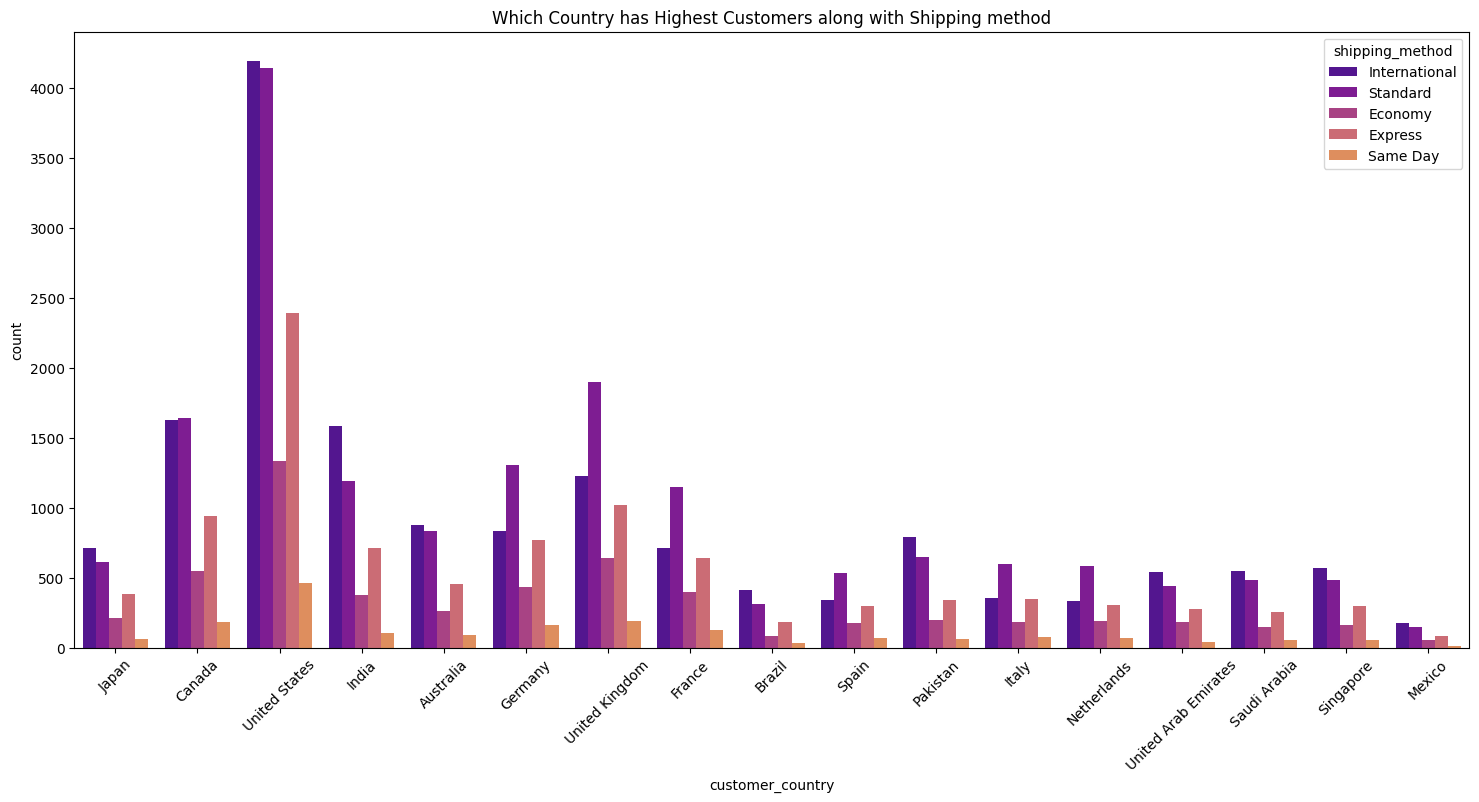

In [5]:
plt.figure(figsize=(18,8))
sns.set_palette("plasma")
sns.countplot(x=df["customer_country"],hue=df["shipping_method"])
plt.xticks(rotation=45)
plt.title("Which Country has Highest Customers along with Shipping method")
plt.show()

Text(0.5, 1.0, 'What is Avg Shipping Charges in USD')

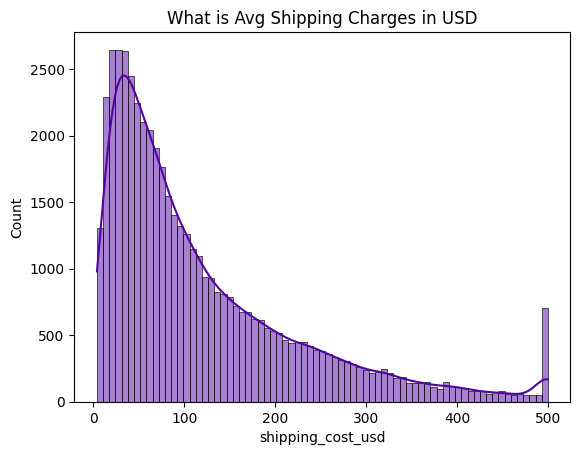

In [6]:
sns.histplot(df["shipping_cost_usd"],kde=True)
plt.title("What is Avg Shipping Charges in USD")

In [7]:
df.describe()

,product_weight_kg,order_value_usd,distance_km,promised_delivery_days,actual_delivery_days,delivery_delay_days,shipping_cost_usd,customer_rating,delivery_attempts,warehouse_processing_hours
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2.255028,177.917107,2496.778802,7.197700,8.345940,1.281080,120.515538,3.371840,1.169860,14.412430
std,3.694952,291.600047,1774.633152,3.680229,4.644353,1.679527,108.680030,0.998777,0.390756,9.924904
min,0.100000,10.000000,40.000000,0.000000,0.000000,0.000000,4.050000,1.000000,1.000000,1.000000
25%,0.320000,28.720000,1086.775000,4.000000,5.000000,0.000000,40.640000,3.000000,1.000000,6.600000
50%,0.930000,76.840000,2182.800000,6.000000,8.000000,1.000000,82.970000,3.000000,1.000000,11.900000
75%,2.610000,173.162500,3592.475000,11.000000,12.000000,2.000000,167.422500,4.000000,1.000000,20.700000
max,52.190000,3530.730000,9553.600000,15.000000,27.000000,13.000000,500.000000,5.000000,3.000000,48.000000


### 1. Feature Engineering: Datetime Deconstruction

* **What was done:**
  Converted `order_date` from a generic object string into a datetime data type, then extracted individual temporal features: day, month, year, day name, and a binary weekend indicator[span_0](start_span)[span_0](end_span).
* **Why specific functions were used:**
  * `pd.to_datetime(..., errors="coerce")`: Safely parses raw strings into standard pandas datetime objects while replacing unparseable date entries with `NaT` (Not a Time) to prevent runtime errors[span_1](start_span)[span_1](end_span).
  * `.dt.day`, `.dt.month`, `.dt.year`: Decomposes flat date strings into discrete numerical components that models can evaluate for seasonal, monthly, or yearly trends[span_2](start_span)[span_2](end_span).
  * `.dt.day_name()`: Extracts human-readable categorical day names (e.g., "Monday") to analyze operational variations across days of the week[span_3](start_span)[span_3](end_span).
  * `.dt.dayofweek.isin([5, 6]).astype(int)`: Identifies Saturdays (5) and Sundays (6), creating a binary flag (`1` for weekend, `0` for weekday) because logistics, dispatching, and shipping rates often change on weekends[span_4](start_span)[span_4](end_span).

---

### 2. Feature Engineering: Domain-Specific Ratios & Signals

* **What was done:**
  Engineered four domain-specific numerical and binary indicator features combining delivery times, delay thresholds, return requests, and route processing efficiency[span_5](start_span)[span_5](end_span).
* **Why specific functions were used:**
  * `df["delivery_diff"] = df["actual_delivery_days"] - df["promised_delivery_days"]`: Measures exact delivery performance delta in days[span_6](start_span)[span_6](end_span). Positive numbers highlight late deliveries, while negative numbers represent early arrivals[span_7](start_span)[span_7](end_span).
  * `df["delay_ratio"] = df["actual_delivery_days"] / (df["promised_delivery_days"] + 1e-5)`: Computes proportional delivery delay[span_8](start_span)[span_8](end_span). Adding `1e-5` prevents catastrophic division-by-zero errors if promised delivery days equal zero[span_9](start_span)[span_9](end_span).
  * `df["is_returned"] = (df["return_requested"] == "Yes").astype(int)`: Converts text labels ("Yes"/"No") into machine-readable numeric binary signals (`1` or `0`)[span_10](start_span)[span_10](end_span).
  * `df["processing_ratio"] = df["warehouse_processing_hours"] / (df["distance_km"] + 1e-5)`: Measures warehouse operational efficiency relative to shipping distance, capturing fulfillment bottleneck dynamics per kilometer traveled[span_11](start_span)[span_11](end_span).

---

### 3. Verification of New Features

* **What was done:**
  Displayed the top 5 rows of the modified DataFrame to confirm all newly created columns were properly calculated and added[span_12](start_span)[span_12](end_span).
* **Why specific functions were used:**
  * `df.head()`: Validates column count expansion (expanding from original columns to 37 total columns) and verifies feature formatting before proceeding to preprocessing[span_13](start_span)[span_13](end_span).

In [8]:
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

# Now new columns
df["day"] = df["order_date"].dt.day
df["month"] = df["order_date"].dt.month
df["year"] = df["order_date"].dt.year

df["day_of_week"] = df["order_date"].dt.day_name()
df["is_weekend"] = df["order_date"].dt.dayofweek.isin([5, 6]).astype(int)


In [9]:
#1.Delivery Performance Delta(Delta=Difference)
df["delivery_diff"] = df["actual_delivery_days"] - df["promised_delivery_days"]

#2.Delay Severity Ratio
df["delay_ratio"] = df["actual_delivery_days"] /(df["promised_delivery_days"]+1e-5)

#3.Return Flag
df["is_returned"] = (df["return_requested"] == "Yes").astype(int)

#4.Route Processing Efficiency
df["processing_ratio"] = df["warehouse_processing_hours"] /(df["distance_km"]+1e-5)


In [10]:
df.head()

,order_date,customer_segment,customer_city,customer_country,warehouse_id,warehouse_city,product_category,product_weight_kg,order_value_usd,shipping_method,...,tracking_status,day,month,year,day_of_week,is_weekend,delivery_diff,delay_ratio,is_returned,processing_ratio
0,2026-11-15,Small Business,Tokyo,Japan,WH-004,Toronto,Home & Kitchen,8.23,10.39,International,...,Delivered,15,11,2026,Sunday,1,5,1.454544,1,0.015891
1,2026-04-08,Consumer,Vancouver,Canada,WH-007,Paris,Beauty,0.10,117.69,Standard,...,Delivered,8,4,2026,Wednesday,0,0,0.999998,0,0.024690
2,2026-01-05,Consumer,Houston,United States,WH-005,London,Home & Kitchen,5.51,335.23,International,...,Delivered,5,1,2026,Monday,0,4,1.333332,1,0.006919
3,2026-05-29,Small Business,Delhi,India,WH-002,Los Angeles,Grocery,3.75,10.57,Standard,...,In Transit,29,5,2026,Friday,0,3,1.374998,0,0.001781
4,2026-02-22,Small Business,Nagoya,Japan,WH-006,Berlin,Beauty,0.10,31.37,Economy,...,Delivered,22,2,2026,Sunday,1,4,1.499998,0,0.047701


### 1. Feature Selection & Target Definition

* **What was done:**
  Selected relevant predictor features into `feature_cols`, extracted feature matrix `X`, and designated `shipping_cost_usd` as target variable `y`.
* **Why specific functions were used:**
  * `X = df[feature_cols]`: Filters the DataFrame down to predictive features, dropping direct outcome proxies or post-delivery metrics to enforce leak-proof modeling boundaries.
  * `y = df["shipping_cost_usd"]`: Isolates continuous target values for regression task modeling.

---

### 2. Leak-Proof Train-Test Dataset Splitting

* **What was done:**
  Split predictors `X` and target `y` into training (80%) and test (20%) sets using fixed random seeding.
* **Why specific functions were used:**
  * `train_test_split(..., test_size=0.20, random_state=42)`: Holds out 20% of data for unbiased out-of-sample evaluation. Executing this split prior to transformation steps guarantees zero data leakage into preprocessing parameters.

---

### 3. Pipeline Construction, Preprocessing, Ensemble Modeling & Initial Evaluation

* **What was done:**
  Defined feature column lists, built a `ColumnTransformer` with forced DataFrame output, initialized `PCA` and a soft-voting ensemble (`Ridge`, `LGBMRegressor`, `XGBRegressor`), wrapped everything inside an end-to-end `Pipeline`, and evaluated initial performance metrics.
* **Why specific functions were used:**
  * `ColumnTransformer(...)`: Applies target transformations (`StandardScaler` for numerical, `OneHotEncoder` for categorical) across specific feature subsets simultaneously.
  * `handle_unknown="ignore"`: Prevents pipeline failures when unseen categorical levels appear during test or inference evaluation.
  * `set_output(transform="pandas")`: Enforces output pandas DataFrame representation with explicit feature names, preventing scikit-learn feature-name warnings downstream.
  * `PCA(n_components=0.95)`: Projects transformed features into lower-dimensional orthogonal principal components capturing 95% variance.
  * `VotingRegressor(...)`: Combines predictions from diverse base algorithms (`Ridge` linear model, `LGBMRegressor`, `XGBRegressor` gradient boosters) to reduce variance and improve model generalization.
  * `Pipeline(steps=[...])`: Chains preprocessing, dimensionality reduction, and estimation steps into a single object, ensuring strict isolation during `fit()` and `predict()` calls.
  * `r2_score()` & `mean_squared_error()`: Quantitative metrics used to measure model accuracy and average squared error magnitude.
* **Executed Baseline Results (With PCA):**
  * **$R^2$ Score:** `0.9650`
  * **RMSE:** `20.0413`
  * *Note:* While compressing features via PCA yielded strong baseline scores ($R^2 = 0.9650$), removing PCA in the subsequent step restored lost variance information and significantly improved test accuracy ($R^2 = 0.9814$, RMSE = $14.6068$).
  * 

In [11]:
feature_cols = ["product_weight_kg", "order_value_usd", "distance_km", "warehouse_processing_hours", "day", "month", "year","is_weekend", "processing_ratio",
    "customer_segment", "customer_country", "warehouse_id", 
    "shipping_method", "carrier", "weather_condition", "day_of_week", "package_size"]

X = df[feature_cols]
y = df["shipping_cost_usd"]


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)


In [13]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor
from sklearn.metrics import mean_squared_error, r2_score


num_cols = ["product_weight_kg", "order_value_usd", "distance_km", "warehouse_processing_hours", "day", "month", "year","is_weekend", "processing_ratio"]
cat_cols = ["customer_segment", "customer_country", "warehouse_id", "shipping_method", "carrier", "weather_condition", "day_of_week", "package_size"]

#Preprocessing & Dimensionality Reduction (Forced DataFrame Output)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)],
    verbose_feature_names_out=False).set_output(transform="pandas")

pca = PCA(n_components=0.95, random_state=42).set_output(transform="pandas")

# Voting Ensemble Regressor(Just like Avg of models)
ensemble = VotingRegressor(
    estimators=[
        ("ridge", Ridge(alpha=1.0)),
        ("lgbm", LGBMRegressor(random_state=42, verbosity=-1)),
        ("xgb", XGBRegressor(random_state=42))])

# Leak-Proof End-to-End Pipeline
clean_pipeline = Pipeline(steps=[
    ("prep", preprocessor),
    ("pca", pca),
    ("ensemble", ensemble)
])

# Fitting & Evaluate
clean_pipeline.fit(X_train, y_train)

y_pred = clean_pipeline.predict(X_test)
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")


R2 Score: 0.9650
RMSE: 20.0413


In [14]:
# Pipeline without PCA
no_pca_pipeline = Pipeline(steps=[
    ("prep", preprocessor),
    ("ensemble", ensemble)
])

no_pca_pipeline.fit(X_train, y_train)

y_pred_no_pca = no_pca_pipeline.predict(X_test)
print(f"R2 Score (Without PCA): {r2_score(y_test, y_pred_no_pca):.4f}")
print(f"RMSE (Without PCA): {np.sqrt(mean_squared_error(y_test, y_pred_no_pca)):.4f}")


R2 Score (Without PCA): 0.9814
RMSE (Without PCA): 14.6068


### 5-Fold Cross-Validation & Model Stability Verification

* **What was done:**
  Evaluated the pipeline without PCA (`no_pca_pipeline`) using 5-fold cross-validation on the training set to check for variance stability and rule out overfitting.
* **Why specific functions were used:**
  * `from sklearn.model_selection import cross_val_score`: Imports the cross-validation scoring utility to evaluate generalized model performance across multiple train-validation subsets.
  * `cross_val_score(no_pca_pipeline, X_train, y_train, cv=5, scoring="r2", n_jobs=-1)`: Splits the training dataset into 5 equal subsets (folds), iteratively training on 4 folds and validating on the 5th. `scoring="r2"` measures goodness of fit per fold, while `n_jobs=-1` utilizes all available CPU cores to speed up computation.
  * `cv_scores.mean()` & `cv_scores.std()`: Calculates the average score across all folds alongside the standard deviation to quantify variance and performance consistency.
* **Executed Validation Results:**
  * **Individual Fold $R^2$ Scores:** `[0.9816, 0.9816, 0.9817, 0.9812, 0.9816]`
  * **Mean CV $R^2$ Score:** `0.9815` ($\pm$ `0.0002`)
  * **Interpretation:** The standard deviation of $\pm 0.0002$ proves near-zero variance across splits. Furthermore, the average CV score ($0.9815$) aligns almost identically with the holdout test set score ($0.9814$), confirming zero overfitting and zero data leakage.

In [15]:
from sklearn.model_selection import cross_val_score

# 5-Fold Cross Validation on Training Data to check if model is overfitting or not
cv_scores = cross_val_score(no_pca_pipeline, X_train, y_train, cv=5, scoring="r2", n_jobs=-1)

print(f"\n--- 5-Fold Cross-Validation R2 Scores ---")
print(f"Fold Scores: {cv_scores.round(4)}")
print(f"Mean CV R2 Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")



--- 5-Fold Cross-Validation R2 Scores ---
Fold Scores: [0.9816 0.9816 0.9817 0.9812 0.9816]
Mean CV R2 Score: 0.9815 (+/- 0.0002)


### SHAP Model Interpretability Analysis (Beeswarm Summary Plot)

* **What was done:**
  Transformed the raw test features through the fitted preprocessing step, extracted the LightGBM estimator from the Voting Regressor ensemble, calculated Tree SHAP (SHapley Additive exPlanations) values, and rendered a beeswarm summary plot for the top 12 features[span_0](start_span)[span_0](end_span).

* **Why specific functions were used:**
  * `import shap`: Imports the SHAP library, which applies game theory principles to explain machine learning predictions by calculating individual feature contributions[span_1](start_span)[span_1](end_span).
  * `no_pca_pipeline.named_steps["prep"].transform(X_test)`: Applies the fitted scaler and one-hot encoder to `X_test` so the extracted model receives properly formatted numerical data matching its input structure[span_2](start_span)[span_2](end_span).
  * `no_pca_pipeline.named_steps["ensemble"].named_estimators_["lgbm"]`: Accesses the trained `LGBMRegressor` model inside the `VotingRegressor` ensemble to pass directly into the tree explainer[span_3](start_span)[span_3](end_span).
  * `shap.TreeExplainer(...)`: An optimized algorithm designed specifically for tree-based models (like LightGBM) to compute exact feature attribution values in linear time[span_4](start_span)[span_4](end_span).
  * `shap.summary_plot(..., max_display=12)`: Generates a beeswarm plot displaying feature importance ranking alongside directional impact on predictions for individual test samples[span_5](start_span)[span_5](end_span).

---

### Understanding the SHAP Beeswarm Plot (Detailed Visual Insights)

#### **1. How to Read the Axes & Colors:**
* **Y-Axis (Features):** Features are listed from top to bottom in order of overall importance. Features near the top have the largest overall impact on predicted shipping costs[span_6](start_span)[span_6](end_span).
* **X-Axis (SHAP Value):** Represents the dollar impact on the predicted shipping cost[span_7](start_span)[span_7](end_span):
  * **Positive SHAP values (right of $0.0$):** Increases the predicted shipping cost[span_8](start_span)[span_8](end_span).
  * **Negative SHAP values (left of $0.0$):** Decreases the predicted shipping cost[span_9](start_span)[span_9](end_span).
* **Color Scale (Feature Value):**
  * **Red (High Value):** Indicates a high numerical value or active binary presence (`1`)[span_10](start_span)[span_10](end_span).
  * **Blue (Low Value):** Indicates a low numerical value or inactive binary presence (`0`)[span_11](start_span)[span_11](end_span).

---

#### **2. Detailed Key Feature Breakdown:**

* **`distance_km` (Single Largest Cost Driver):**
  * **Visual Behavior:** A wide spread extending up to $+300$ on the x-axis[span_12](start_span)[span_12](end_span).
  * **Insight:** High distances (red dots) push shipping costs upward significantly—adding up to **+$300 USD** to the baseline prediction[span_13](start_span)[span_13](end_span). Conversely, shorter distances (blue dots) push costs into negative SHAP territory (around **-$60 USD** to **-$100 USD**)[span_14](start_span)[span_14](end_span). Distance is overwhelmingly the most influential factor.

* **`shipping_method_International`:**
  * **Visual Behavior:** Red points cluster on the positive side (around $+30$ to $+60$)[span_15](start_span)[span_15](end_span).
  * **Insight:** Selecting international shipping automatically adds a substantial price premium to the total cost[span_16](start_span)[span_16](end_span).

* **`product_weight_kg`:**
  * **Visual Behavior:** Higher weight values (red dots) extend to the right (up to $+80$)[span_17](start_span)[span_17](end_span).
  * **Insight:** Heavier packages consistently drive up shipping costs due to higher fuel and freight charges[span_18](start_span)[span_18](end_span).

* **`package_size_Small` vs. `package_size_Oversized`:**
  * **Small Packages:** Red points sit on the negative side (left of $0.0$), showing that small sizes decrease expected shipping fees[span_19](start_span)[span_19](end_span).
  * **Oversized Packages:** Red points sit entirely on the positive side, indicating a fixed price jump for oversized handling[span_20](start_span)[span_20](end_span).

* **`shipping_method_Economy` vs. `shipping_method_Same Day`:**
  * **Economy Shipping:** Red points shift left (negative impact), confirming economy options provide noticeable savings[span_21](start_span)[span_21](end_span).
  * **Same Day Shipping:** Red points shift far right (up to $+120$), reflecting a heavy premium for expedited same-day dispatching[span_22](start_span)[span_22](end_span).

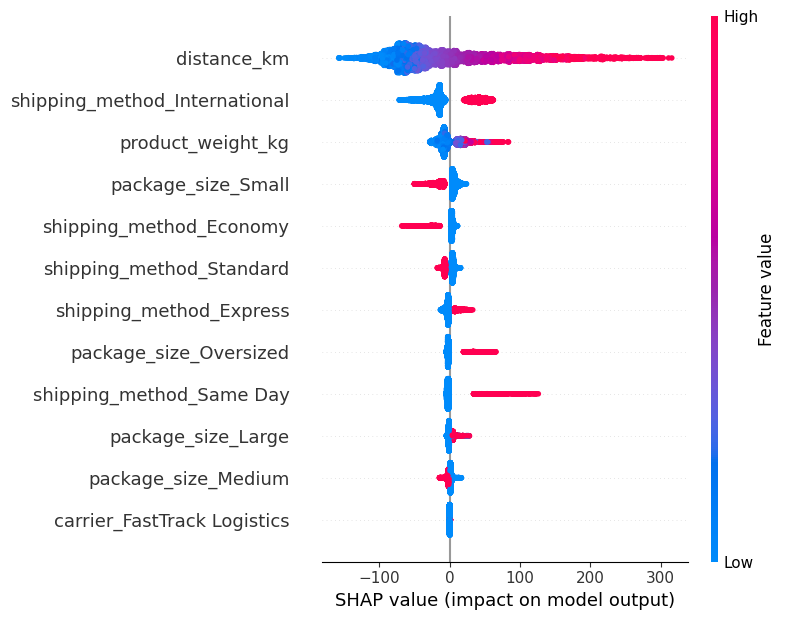

In [16]:
import shap
import matplotlib.pyplot as plt

# 1. Transform X_test through the preprocessor step
X_test_transformed = no_pca_pipeline.named_steps["prep"].transform(X_test)

# 2. Extract LightGBM regressor from the fitted VotingRegressor
lgbm_regressor = no_pca_pipeline.named_steps["ensemble"].named_estimators_["lgbm"]

# 3. Compute Tree SHAP values
explainer = shap.TreeExplainer(lgbm_regressor)
shap_values = explainer(X_test_transformed)

# 4. Generate SHAP Beeswarm Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_transformed, max_display=12)


In [17]:
import joblib
from sklearn.metrics import r2_score

# 1. Save (serialize) the trained pipeline to disk
model_filename = "shipping_cost_pipeline.pkl"
joblib.dump(no_pca_pipeline, model_filename)
print(f"Model pipeline successfully saved as '{model_filename}'")

# 2. Load (deserialize) the trained pipeline back into memory
loaded_pipeline = joblib.load(model_filename)
print(f"Model pipeline successfully reloaded from '{model_filename}'")

# 3. Verify loaded model performance on test data
y_pred_loaded = loaded_pipeline.predict(X_test)
print(f"Reloaded Model Test R2 Score: {r2_score(y_test, y_pred_loaded):.4f}")


Model pipeline successfully saved as 'shipping_cost_pipeline.pkl'
Model pipeline successfully reloaded from 'shipping_cost_pipeline.pkl'
Reloaded Model Test R2 Score: 0.9814
